In [40]:
import pandas as pd
odf = pd.read_csv("combined_data.csv",index_col = 0)
odf

,Frame,time_sec,angle_1_deg,angle_2_deg,angle_3_deg,angle_4_deg,angle_5_deg,angle_6_deg,angular_velocity_1_deg_per_s,angular_velocity_2_deg_per_s,...,rom_1s_angle_1_deg,rom_1s_angle_2_deg,rom_1s_angle_3_deg,rom_1s_angle_4_deg,rom_1s_angle_5_deg,rom_1s_angle_6_deg,symmetry_absdiff_angle_1_vs_2_deg,symmetry_absdiff_angle_3_vs_4_deg,symmetry_absdiff_angle_5_vs_6_deg,LDF_bloodflow
0,0,0.0,129.590014,116.175985,124.912264,138.465878,148.037279,139.156722,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.414029,13.553614,8.880557,78.2
3,3,0.1,119.970511,126.642806,118.266606,138.792536,143.960011,137.516050,-42.109766,74.796472,...,9.619503,10.466821,6.645658,1.167229,4.077268,1.640673,6.672294,20.525930,6.443962,70.3
6,6,0.2,118.394850,120.576245,114.231931,138.109628,136.118053,142.061438,-65.866072,-117.216631,...,11.195164,10.824471,10.680334,1.195055,11.919226,5.010976,2.181395,23.877697,5.943385,49.2
9,9,0.3,110.740615,116.207194,110.173619,137.729528,136.320260,127.414221,-273.647234,-237.670210,...,18.849399,10.824471,14.738646,1.195055,16.785536,16.056951,5.466579,27.555909,8.906040,45.8
12,12,0.4,119.378066,128.308051,109.435626,137.684705,131.934455,129.129593,161.069123,260.521499,...,18.849399,13.227142,15.476639,2.058446,16.785536,16.056951,8.929985,28.249080,2.804863,51.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16830,16830,561.0,106.776337,128.964524,119.191217,63.353146,159.059405,161.310681,124.121808,-21.826813,...,47.056548,32.007998,39.319078,75.896277,9.197877,16.149978,22.188187,55.838071,2.251276,NaN
16833,16833,561.1,101.395593,130.427763,125.541303,60.752745,158.453255,162.549781,-399.834801,-32.894259,...,47.056548,32.007998,39.319078,71.506817,9.197877,16.956117,29.032170,64.788558,4.096526,NaN
16836,16836,561.2,104.116091,129.284041,117.807976,61.799694,154.592711,153.436793,0.617912,92.819713,...,42.303320,20.761680,35.192154,44.409504,9.197877,13.988992,25.167950,56.008282,1.155918,NaN
16839,16839,561.3,113.012458,129.271175,106.328327,64.365965,157.092217,157.516273,83.685977,-24.063160,...,42.303320,20.761680,35.192154,16.661957,9.197877,9.266410,16.258717,41.962362,0.424057,NaN


In [ ]:
#Make a copy of odf
df = odf.copy()
#Change shift 0 to shift1, shift2, ... shift 10 if it wasn't accurate
df['LDF_bloodflow'] = df['LDF_bloodflow'].shift(-20)
#Removes rows with NaN values that would prevent machine learning
df = df.dropna()

In [ ]:

#Example of Simplest Machine Learnign Code
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#X = Everything other than LDF bloodflow
X = df.drop(columns=['LDF_bloodflow'])
#y = LDF bloodflow
y = df['LDF_bloodflow']

#Splitting Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [38]:
#Example of Simplest Code to Evaluate Performance of Machine Learning Model
from sklearn.metrics import mean_absolute_error, r2_score
lr_preds = lr_model.predict(X_test)
print("--- Linear Regression Performance ---")
print(f"MAE: {mean_absolute_error(y_test, lr_preds):.4f}")
print(f"R2 Score: {r2_score(y_test, lr_preds):.4f}\n")

--- Linear Regression Performance ---
MAE: 83.4034
R2 Score: -0.8537



R2 Score of -0.45 meaning very bad: it means the model performs worse than random guessing
R2 Score = 0 Means Model is randomly guessing
R2 Score of 0.8 and above is good, but different machine learning algorithm also have different metrics

In [68]:
import pandas as pd
for i in range(0, 300):
    odf = pd.read_csv("combined_data.csv",index_col = 0)

    #Make a copy of odf
    df = odf.copy()
    #Change shift 0 to shift1, shift2, ... shift 10 if it wasn't accurate
    df['LDF_bloodflow'] = df['LDF_bloodflow'].shift(-i)
    #Removes rows with NaN values that would prevent machine learning
    df = df.dropna()

    #Example of Simplest Machine Learnign Code
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LinearRegression

    #X = Everything other than LDF bloodflow
    X = df[['angle_6_deg']]
    #y = LDF bloodflow
    y = df['LDF_bloodflow']
    #Splitting Data into Train and Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    #Example of Simplest Code to Evaluate Performance of Machine Learning Model
    from sklearn.metrics import mean_absolute_error, r2_score
    lr_preds = lr_model.predict(X_test)
    print(f"--- Linear Regression Performance --- for shift {i}")
    print(f"MAE: {mean_absolute_error(y_test, lr_preds):.4f}")
    print(f"R2 Score: {r2_score(y_test, lr_preds):.4f}\n")

--- Linear Regression Performance --- for shift 0
MAE: 62.5368
R2 Score: 0.0064

--- Linear Regression Performance --- for shift 1
MAE: 60.8164
R2 Score: 0.0023

--- Linear Regression Performance --- for shift 2
MAE: 62.5572
R2 Score: 0.0077

--- Linear Regression Performance --- for shift 3
MAE: 60.3014
R2 Score: 0.0116

--- Linear Regression Performance --- for shift 4
MAE: 61.4433
R2 Score: 0.0054

--- Linear Regression Performance --- for shift 5
MAE: 62.2260
R2 Score: 0.0090

--- Linear Regression Performance --- for shift 6
MAE: 60.5946
R2 Score: -0.0091

--- Linear Regression Performance --- for shift 7
MAE: 61.8304
R2 Score: 0.0017

--- Linear Regression Performance --- for shift 8
MAE: 61.2003
R2 Score: 0.0028

--- Linear Regression Performance --- for shift 9
MAE: 60.1893
R2 Score: 0.0108

--- Linear Regression Performance --- for shift 10
MAE: 63.0552
R2 Score: -0.0029

--- Linear Regression Performance --- for shift 11
MAE: 59.6793
R2 Score: 0.0131

--- Linear Regression Pe

c:\Python312\Lib\site-packages\scipy\signal\_signaltools.py:247: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return convolve(in1, _reverse_and_conj(in2), mode, method)


Best lag: -5614
Time delay (seconds): -561.4


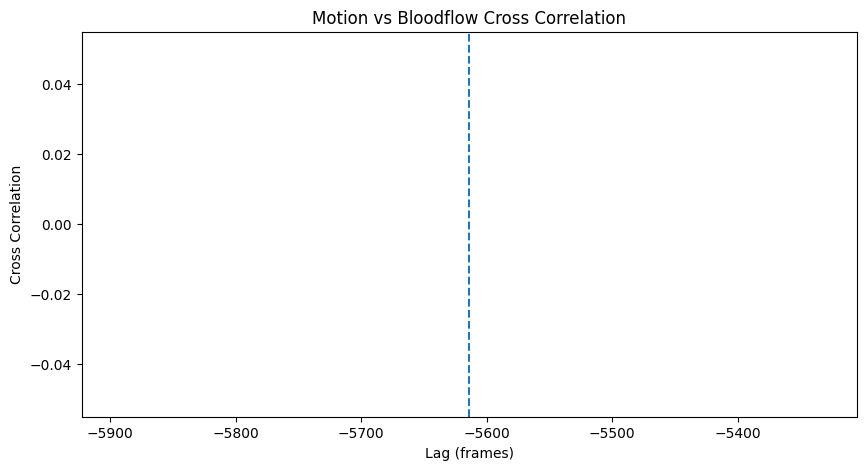

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Load data
df = pd.read_csv("combined_data.csv", index_col=0)

# Separate X and y
X = df.drop(columns=["LDF_bloodflow"])
y = df["LDF_bloodflow"]

# Motion intensity signal
motion = X.diff().abs().sum(axis=1)

# Standardize
motion = (motion - motion.mean()) / motion.std()
bloodflow = (y - y.mean()) / y.std()

# Cross correlation
corr = correlate(motion, bloodflow, mode='full')

# Lags
lags = np.arange(-len(motion)+1, len(bloodflow))

# Best lag
best_lag = lags[np.argmax(corr)]

print("Best lag:", best_lag)
print("Time delay (seconds):", best_lag * 0.1)

# Plot
plt.figure(figsize=(10,5))
plt.plot(lags, corr)
plt.axvline(best_lag, linestyle='--')
plt.xlabel("Lag (frames)")
plt.ylabel("Cross Correlation")
plt.title("Motion vs Bloodflow Cross Correlation")
plt.show()


BEST SHIFT FOUND
shift   -201.000000
r2         0.107022
Name: 99, dtype: float64


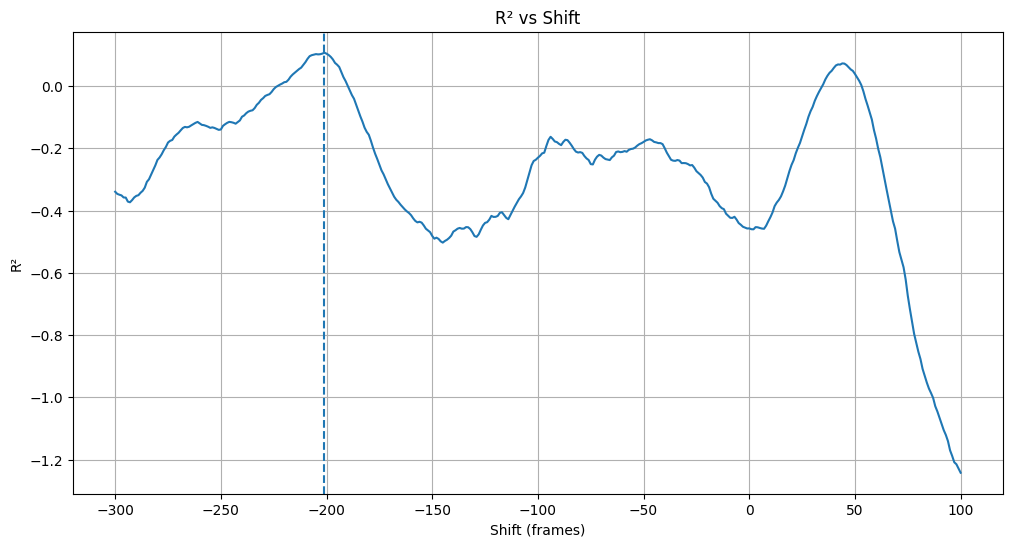

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

odf = pd.read_csv("combined_data.csv", index_col=0)

results = []

for shift in range(-300, 101):

    df = odf.copy()

    # Apply shift
    df['LDF_bloodflow'] = df['LDF_bloodflow'].shift(-shift)

    # Remove NaNs created by shifting
    df = df.dropna()

    X = df.drop(columns=['LDF_bloodflow'])
    y = df['LDF_bloodflow']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)

    results.append((shift, r2))

results_df = pd.DataFrame(results, columns=["shift", "r2"])

best_row = results_df.loc[results_df["r2"].idxmax()]

print("\nBEST SHIFT FOUND")
print(best_row)

plt.figure(figsize=(12,6))
plt.plot(results_df["shift"], results_df["r2"])
plt.axvline(best_row["shift"], linestyle="--")
plt.xlabel("Shift (frames)")
plt.ylabel("R²")
plt.title("R² vs Shift")
plt.grid(True)
plt.show()